In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB
None


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

print(df.dtypes)

Дата            datetime64[ns]
Склад                    int64
Контрагент              object
Номенклатура            object
Количество               int64
dtype: object


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').size().reset_index(name='sales_count')

print(grouped_df.head())

        Дата  sales_count
0 2018-01-04         1840
1 2018-01-05         1301
2 2018-01-06         1306
3 2018-01-07         1322
4 2018-01-09         1719


Вывести несколько первых строк сгруппированных данных

In [7]:
print(grouped_df.head())

        Дата  sales_count
0 2018-01-04         1840
1 2018-01-05         1301
2 2018-01-06         1306
3 2018-01-07         1322
4 2018-01-09         1719


Нарисуйте график продаж у `grouped_df`

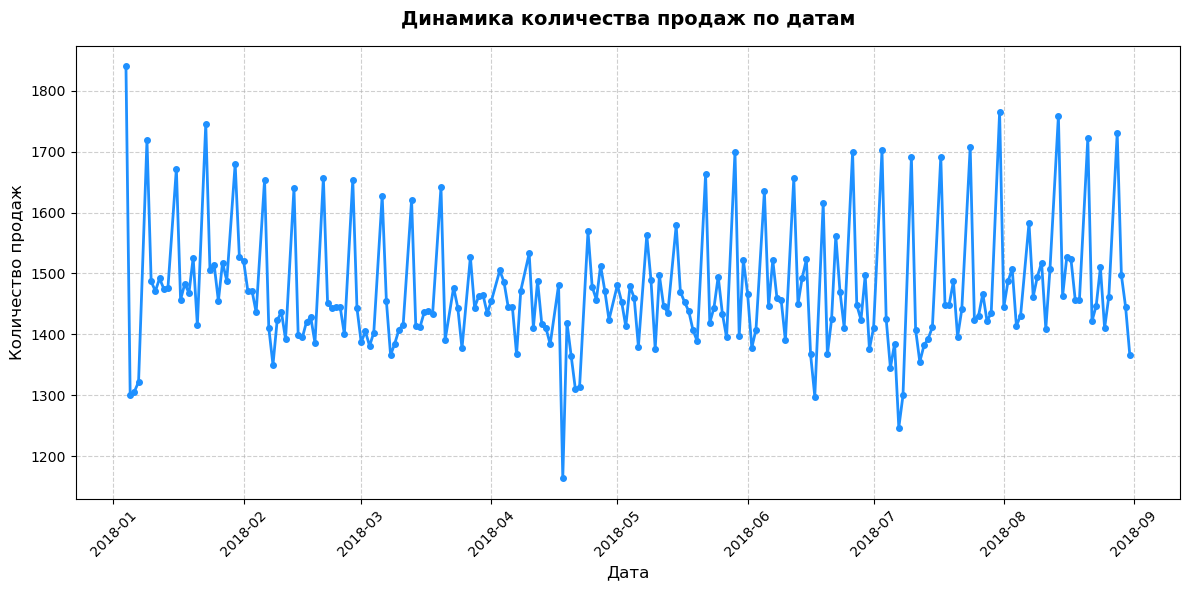

In [8]:
plt.figure(figsize=(12, 6))

plt.plot(grouped_df['Дата'], grouped_df['sales_count'], color='dodgerblue', linewidth=2, marker='o', markersize=4)

plt.title('Динамика количества продаж по датам', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество продаж', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

## Описание графика

Базовый уровень: Продажи стабильны и идут в коридоре 1350–1700 операций в день. Долговременного роста или падения нет.

Цикличность: График имеет «пилообразную» форму — это явная недельная сезонность.

Главный пик: Начало января — более 1840 продаж.

Главный провал: Середина апреля — падение до 1160 продаж.

Летний период: С июня по август амплитуда скачков усиливается — бизнес штормит сильнее, чем весной.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [9]:
max_sales_idx = grouped_df['sales_count'].idxmax()

peak_day = grouped_df.loc[max_sales_idx]

print("Строка с максимальным выбросом:")
print(peak_day)

Строка с максимальным выбросом:
Дата           2018-01-04 00:00:00
sales_count                   1840
Name: 0, dtype: object


Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [10]:
filtered_df = df[
    (df['Склад'] == 3) & 
    (df['Дата'].dt.month.isin([6, 7, 8])) & 
    (df['Дата'].dt.dayofweek == 2)
]

top_item = filtered_df.groupby('Номенклатура')['Количество'].sum().reset_index()

top_item = top_item.sort_values(by='Количество', ascending=False).head(1)

print("Топовый товар по продажам по средам за лето у 3-го склада:")
print(top_item)

Топовый товар по продажам по средам за лето у 3-го склада:
  Номенклатура  Количество
1    product_1        2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

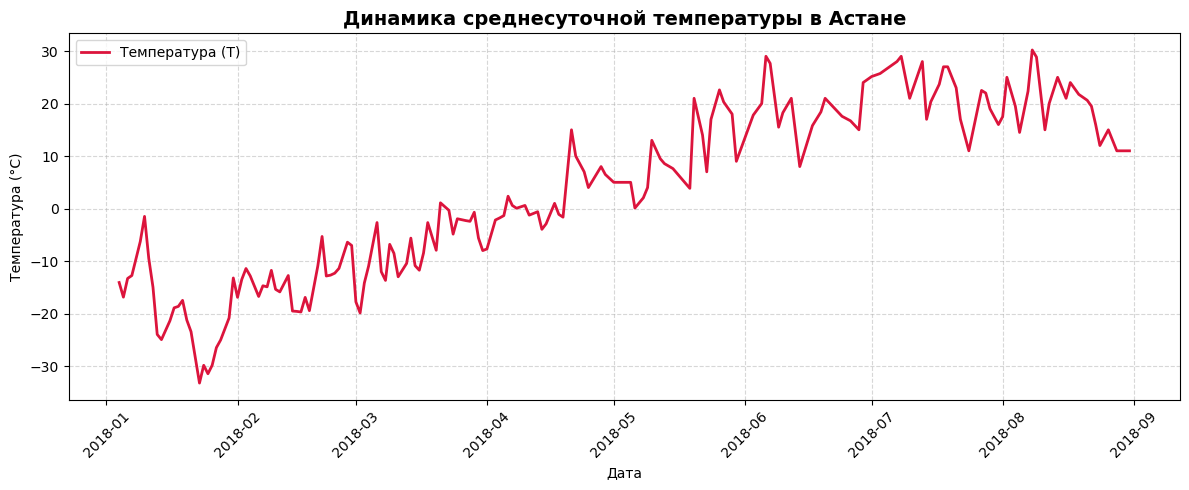

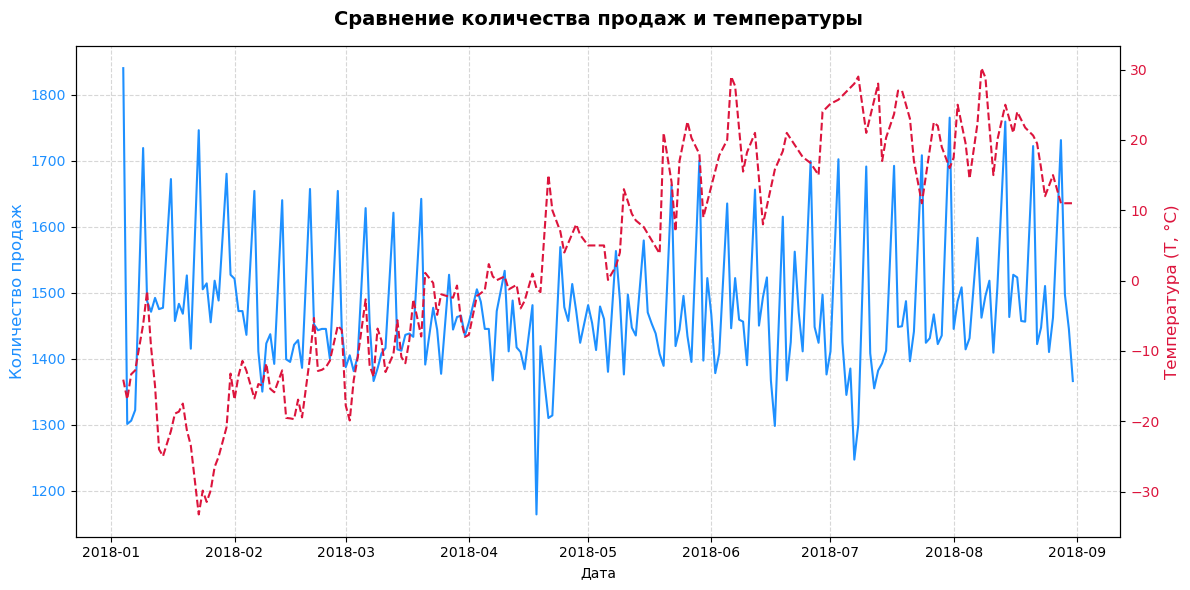

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('data.csv')
df['Дата'] = pd.to_datetime(df['Дата'])
grouped_df = df.groupby('Дата').size().reset_index(name='sales_count')
grouped_df['Дата'] = pd.to_datetime(grouped_df['Дата']).dt.normalize()

weather_df = pd.read_excel('weather.xlsx', skiprows=6)

time_col = weather_df.columns[0]
temp_col = weather_df.columns[1]

weather_df['Clean_Date'] = pd.to_datetime(weather_df[time_col], dayfirst=True, errors='coerce').dt.normalize()
weather_df['T'] = pd.to_numeric(weather_df[temp_col], errors='coerce')

weather_df = weather_df.dropna(subset=['Clean_Date'])

daily_weather = weather_df.groupby('Clean_Date')['T'].mean().reset_index()
daily_weather.rename(columns={'Clean_Date': 'Дата'}, inplace=True)

merged_df = pd.merge(grouped_df, daily_weather, on='Дата', how='inner')
merged_df = merged_df.sort_values(by='Дата')

merged_df['T'] = merged_df['T'].interpolate(method='linear')

plt.figure(figsize=(12, 5))
plt.plot(merged_df['Дата'], merged_df['T'], color='crimson', label='Температура (T)', linewidth=2)
plt.title('Динамика среднесуточной температуры в Астане', fontsize=14, fontweight='bold')
plt.xlabel('Дата')
plt.ylabel('Температура (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, ax1 = plt.subplots(figsize=(12, 6))

color = 'dodgerblue'
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество продаж', color=color, fontsize=12)
ax1.plot(merged_df['Дата'], merged_df['sales_count'], color=color, label='Количество продаж', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color = 'crimson'
ax2.set_ylabel('Температура (T, °C)', color=color, fontsize=12)
ax2.plot(merged_df['Дата'], merged_df['T'], color=color, label='Температура (T)', linewidth=1.5, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Сравнение количества продаж и температуры', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()